<a href="https://colab.research.google.com/github/deenmdatif/machine-learning-projects/blob/main/Restaurant_Reviews_Sentiment_Analysis_NLP_Models_%26_ROC_Curve_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np



In [4]:
df=pd.read_csv('output_file.csv')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


In [5]:
df['Liked'].value_counts()

,count
Liked,
1,500
0,500


In [6]:
df.isnull().sum()

,0
Review,0
Liked,0


In [7]:
df.duplicated().sum()

np.int64(4)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
import re
def remove_tags(raw_text):
    cleaned_text=re.sub(re.compile('<.*?>'),'',raw_text)
    return cleaned_text

In [11]:
df['Review']=df['Review'].apply(remove_tags)

In [12]:
df['Review']=df['Review'].apply(lambda x:x.lower())

In [13]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
sw_list=stopwords.words('english')
df['Review']=df['Review'].apply(lambda x:[item for item in x.split() if item not in sw_list]).apply(lambda x:" ".join(x))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
df

,Review,Liked
0,wow... loved place.,1
1,crust good.,0
2,tasty texture nasty.,0
3,stopped late may bank holiday rick steve recom...,1
4,selection menu great prices.,1
...,...,...
995,think food flavor texture lacking.,0
996,appetite instantly gone.,0
997,overall impressed would go back.,0
998,"whole experience underwhelming, think go ninja...",0


In [15]:
X =df.iloc[:,0:1]
y=df['Liked']


In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [17]:
X_train.shape

(796, 1)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
cv= CountVectorizer(max_features=1000)
X_train_bow=cv.fit_transform(X_train['Review']).toarray()
X_test_bow=cv.transform(X_test['Review']).toarray()

In [19]:
from sklearn.naive_bayes import GaussianNB
gnb= GaussianNB()
gnb.fit(X_train_bow,y_train)

GaussianNB()

In [20]:
y_pred=gnb.predict(X_test_bow)
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_test,y_pred)


0.7

In [21]:
confusion_matrix(y_test,y_pred)

array([[66, 49],
       [11, 74]])

In [22]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(X_train_bow,y_train)
y_pred=rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

0.755

In [23]:
confusion_matrix(y_test,y_pred)

array([[97, 18],
       [31, 54]])

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
cv= CountVectorizer(max_features=1000)
X_train_bow=cv.fit_transform(X_train['Review']).toarray()
X_test_bow=cv.transform(X_test['Review']).toarray()
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(X_train_bow,y_train)
y_pred=rf.predict(X_test_bow)
accuracy_score(y_test,y_pred)

0.745

In [25]:
new_review = ["crust good.	"]
new_vector = cv.transform(new_review).toarray()
prediction = rf.predict(new_vector)
print(prediction)

[0]


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [27]:
# RandomForest
y_prob_rf = rf.predict_proba(X_test_bow)[:,1]

# GaussianNB
y_prob_gnb = gnb.predict_proba(X_test_bow)[:,1]

# # LogisticRegression
# y_prob_lr = lr.predict_proba(X_test_bow)[:,1]

In [28]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_gnb = roc_auc_score(y_test, y_prob_gnb)
# auc_lr = roc_auc_score(y_test, y_prob_lr)

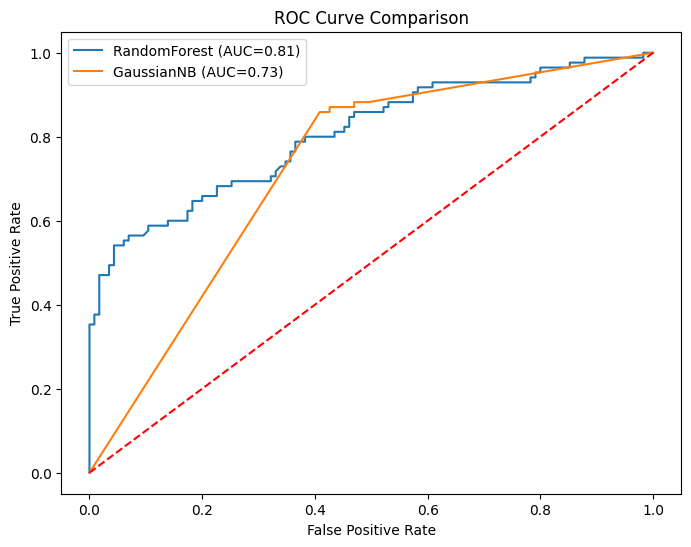

In [29]:
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC={auc_rf:.2f})')
plt.plot(fpr_gnb, tpr_gnb, label=f'GaussianNB (AUC={auc_gnb:.2f})')
#  plt.plot(fpr_lr, tpr_lr, label=f'LogisticRegression (AUC={auc_lr:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()